# End-to-End PU 深度网络：1D ResNet + CN 注意力 

本 notebook 为端到端 PU 深度学习方法，包含：

1. **架构详解** — 1D ResNet 主干 + CN 分子带输入注意力 + SE 通道注意力
2. **注意力训练过程** — 可学习 CN 注意力权重随训练的演化可视化
3. **训练动态** — 损失 / 验证 PR-ROC / 正样本概率崩溃诊断
4. **评估与可视化** — PR/ROC 曲线 + 候选体光谱 + 参数空间
5. **候选体筛选** — 用已知 CN 星概率分布标定阈值（非人工 top-N）

> **注意力训练过程追踪** 与 **已知 CN 星标定阈值** 的候选体筛选


## 0. 环境与依赖

- 运行环境：`myenv`（PyTorch 2.5.1 + CUDA）
- 数据源：`PhaseSummary/_cache`（由 `ensure_cache()` 自动加载/构建）
- 模型模块：`EndToEndPU/models/resnet_cn_attention.py`
- 训练模块：`EndToEndPU/trainer.py`

In [19]:
import sys, os, time, warnings, json
from pathlib import Path
warnings.filterwarnings('ignore')

# 稳健定位项目根目录（无论 notebook 从何处启动）
_PROJECT_ROOT = Path(os.getcwd()).resolve()
for _ in range(6):
    if (_PROJECT_ROOT / 'ML').exists() and (_PROJECT_ROOT / 'Data').exists():
        break
    _PROJECT_ROOT = _PROJECT_ROOT.parent
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 150
matplotlib.rcParams['font.size'] = 10

from sklearn.metrics import (roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, auc)
from sklearn.neighbors import NearestNeighbors

from PhaseSummary.shared.data_loader import (ensure_cache, BAND_DEFS,
    MOLECULAR_BAND_RANGES)

from EndToEndPU.config import EndToEndPUConfig
from EndToEndPU.models.resnet_cn_attention import create_model, CNBandInputAttention
from EndToEndPU.trainer import EndToEndPUTrainer

print(f'PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42

PyTorch 2.5.1  |  CUDA: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 1. 数据加载与划分

数据沿用项目统一的预处理管线：

- 700 像素连续谱归一化光谱（3800–4500 Å，步长 1 Å）
- 33,565 颗恒星，其中 73 颗已知 CN 星（label=1），其余未标注（label=-1）
- 划分策略与 EndToEndPU 方法一致：正样本按 15%/15% 分到 test/val，其余训练

In [ ]:
t0 = time.time()
# ═══════════════════════════════════════════════════════════════════
# 【选择数据缓存】改 CACHE_MODE 即可切换数据集：
#   "old"  → 原缓存      PhaseSummary/_cache  (33,565 星 / 73 CN)
#   "new"  → 新合并缓存  Data/dr13_all_cache  (41,243 星 / 91 CN, feh 扩展到 -2.5)
# ═══════════════════════════════════════════════════════════════════
CACHE_MODE = "new"   # ← 改成 "old" 即切换回原缓存
if CACHE_MODE == "old":
    data = ensure_cache()
    X_clean = data['X_clean'].astype(np.float32)
    stars_clean = data['stars_clean']
    feature_df = data['feature_df']
    common_wave = data['common_wave'].astype(np.float64)
elif CACHE_MODE == "new":
    from build_dr13_all_cache import load_dr13_all_cache
    data = load_dr13_all_cache()
    X_clean = data['X_clean'].astype(np.float32)
    stars_clean = data['stars_clean']
    feature_df = data['feature_df']
    common_wave = data['common_wave'].astype(np.float64)
else:
    raise ValueError(f"未知 CACHE_MODE={CACHE_MODE!r}，可选 'old' 或 'new'")

y = stars_clean['label'].values.astype(int)   # 1 = CN, -1 = unlabeled
N = len(y)
n_pos = int((y == 1).sum())

print(f"数据加载完成 ({time.time()-t0:.1f}s):")
print(f"  光谱矩阵 X_clean: {X_clean.shape}")
print(f"  恒星数: {N:,}  |  已知 CN 星: {n_pos}  |  波长: {common_wave[0]:.0f}-{common_wave[-1]:.0f} Å")

# ── 划分 train / val / test（正样本 15%/15% 分层）──
rng = np.random.RandomState(SEED)
pos_idx = np.where(y == 1)[0]
unl_idx = np.where(y == -1)[0]
rng.shuffle(pos_idx)

n_test = max(1, int(len(pos_idx) * 0.15))
test_pos = pos_idx[:n_test]
rest_pos = pos_idx[n_test:]
n_val = max(1, int(len(rest_pos) * 0.15))
val_pos = rest_pos[:n_val]
train_pos = rest_pos[n_val:]

rng.shuffle(unl_idx)
n_test_unl = max(2000, int(len(unl_idx) * 0.15))
n_val_unl = max(1500, int(len(unl_idx) * 0.15))
test_unl = unl_idx[:n_test_unl]
val_unl = unl_idx[n_test_unl:n_test_unl + n_val_unl]
train_unl = unl_idx[n_test_unl + n_val_unl:]

train_idx = np.concatenate([train_pos, train_unl])
val_idx = np.concatenate([val_pos, val_unl])
test_idx = np.concatenate([test_pos, test_unl])

X_train_pos = X_clean[train_pos]
X_train_unl = X_clean[train_unl]
X_val = X_clean[val_idx]
y_val_bin = (y[val_idx] == 1).astype(np.float32)
X_test = X_clean[test_idx]
y_test_bin = (y[test_idx] == 1).astype(int)

print(f"数据划分 (seed={SEED}):")
print(f"  训练: {len(train_pos)} 正 / {len(train_unl):,} 未标注")
print(f"  验证: {len(val_pos)} 正 / {len(val_unl):,} 未标注")
print(f"  测试: {len(test_pos)} 正 / {len(test_unl):,} 未标注")

从 dr13_all_cache 加载:
  X_clean:      (41243, 700)
  stars_clean:  41,243 行
  feature_df:   (41243, 20)
  已知 CN 星:   91
数据加载完成 (1.9s):
  光谱矩阵 X_clean: (41243, 700)
  恒星数: 41,243  |  已知 CN 星: 91  |  波长: 3800-4499 Å
数据划分 (seed=42):
  训练: 67 正 / 28,808 未标注
  验证: 11 正 / 6,172 未标注
  测试: 13 正 / 6,172 未标注


## 2. 架构详解：SpectraResNet_CN_Attention

```
Input (1, 700)
  -> CNBandInputAttention  可学习波长门控，初始化为 CN/CH 分子带 3× 强调
  -> Stem: Conv1d(1->64, k=7, s=2) -> BN -> ReLU -> MaxPool(k=2, s=2)
  -> layer1: ResBlock1d(64->128, k=7, s=2) + SE
  -> layer2: ResBlock1d(128->256, k=5, s=2) + SE
  -> layer3: ResBlock1d(256->512, k=3, s=2) + SE
  -> layer4: ResBlock1d(512->512, k=3, s=1) + SE
  -> AdaptiveAvgPool1d(1)
  -> FC: 512 -> 128 (LayerNorm) -> ReLU -> Dropout(0.3) -> 1 -> Sigmoid
```

三个关键组件：

1. **CNBandInputAttention（输入波长注意力）**：`x_att = x * softplus(log_w)/mean`，
   初始化时对 CN3839/CN4142/CH4300 三个分子带设 3× 权重，将 SpectraAE "关注 CN 带"
   的思想直接融入分类网络，同时保留可学习自由度。
2. **SE1d（通道注意力）**：Squeeze-and-Excitation，对每个 ResBlock 输出做通道重标定。
3. **ResBlock1d（1D 残差块）**：两卷积 + BN + SE + shortcut，缓解梯度消失。

参数量: 3,814,269 总  |  3,814,269 可训练


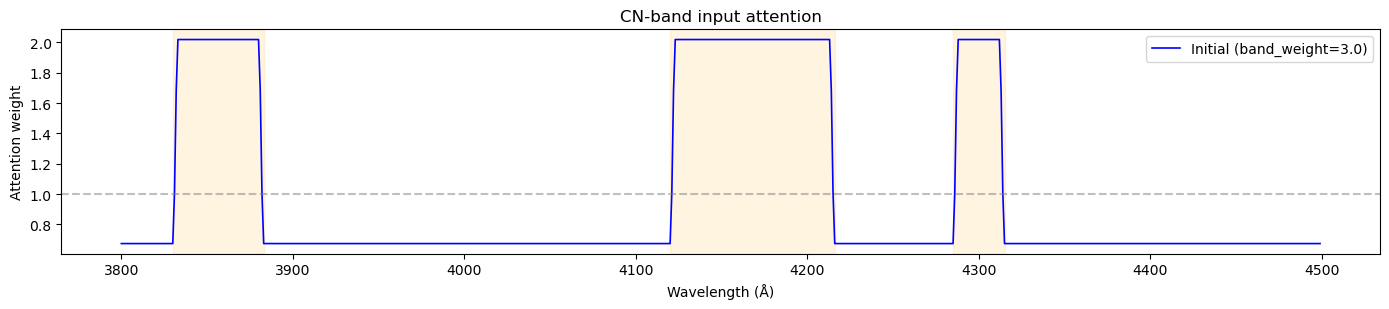

初始 band/continuum 权重比: 2.867


In [21]:
config = EndToEndPUConfig(
    use_cn_attention=True,
    cn_band_weight_init=3.0,
    base_ch=64,
    dropout=0.3,
    se_reduction=8,
    res_blocks=4,
    learning_rate=1e-3,
    weight_decay=1e-2,
    batch_size=64,
    n_epochs=200,
    early_stopping_patience=40,
    loss_mode='weighted_bce',
    positive_weight=10.0,
    neg_ratio=1.0,
    mixup_alpha=0.2,
    pos_augment=True,
    grad_clip=1.0,
    hard_neg_frac=0.3,
    random_seed=SEED,
    device=DEVICE,
)

model = create_model(config)
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"参数量: {n_params:,} 总  |  {n_trainable:,} 可训练")

# 初始 CN 注意力权重（训练前的可学习门控）
init_attn = CNBandInputAttention(n_pixels=700, band_weight_init=3.0)
init_w = init_attn.get_weights().cpu().detach().numpy().flatten()

fig, ax = plt.subplots(figsize=(14, 3.2))
ax.plot(common_wave, init_w, 'b-', lw=1.2, label='Initial (band_weight=3.0)')
ax.axhline(1.0, color='gray', ls='--', alpha=0.5)
for lo, hi in MOLECULAR_BAND_RANGES:
    ax.axvspan(lo, hi, alpha=0.12, color='orange')
ax.set_xlabel('Wavelength (Å)'); ax.set_ylabel('Attention weight')
ax.set_title('CN-band input attention')
ax.legend(); plt.tight_layout(); plt.show()

print(f"初始 band/continuum 权重比: {init_attn.get_band_weight_ratio():.3f}")

## 3. 损失函数与训练策略

**损失（默认加权 BCE，备选 nnPU/uPU）**：

- `weighted_bce`：正样本加权（pos_weight=10）+ 1:1 平衡采样
- `nnPU`（Kiryo et al. 2017）：非负 PU 风险估计
  `R_nnpu = π_p·E_p[ℓ(f,+1)] + max(0, E_u[ℓ(f,-1)] − π_p·E_p[ℓ(f,-1)])`

**训练策略（应对 ~54 个正样本的极端不平衡）**：

- 正样本物理增强（噪声 / RV 抖动 / 连续谱倾斜 / 吸收深度缩放 / mixup）
- Hard negative mining（每 10 epoch 用当前模型重打分，取高分伪负样本）
- Mixup + Dropout + 强 weight decay + 梯度裁剪 + CosineAnnealing + 早停

## 4. 训练

端到端训练 1D ResNet + CN Attention（weighted BCE，200 epoch，早停 patience=40）。
约需 3–5 分钟（GPU）。

In [22]:
print("开始训练（约 3–5 分钟，早停可提前结束）...")
trainer = EndToEndPUTrainer(model, config)
train_result = trainer.train(
    X_train_pos=X_train_pos,
    X_train_unl=X_train_unl,
    X_val=X_val,
    y_val_bin=y_val_bin,
    wave=common_wave if config.pos_augment else None,
    verbose=True,
)
model = train_result['model']
history = train_result['history']
snapshots = train_result['attention_snapshots']
print(f"最优 epoch={train_result['best_epoch']}  "
      f"val PR={train_result['best_val_pr']:.4f}  ROC={train_result['best_val_roc']:.4f}")

开始训练（约 3–5 分钟，早停可提前结束）...
  *Ep   1/200 | loss=1.8871 | pos_p=0.931 unl_p=0.9317 | val_pr=0.0010 val_roc=0.0292 | best=0.0010@1
  *Ep   2/200 | loss=0.5067 | pos_p=0.986 unl_p=0.9194 | val_pr=0.0012 val_roc=0.2238 | best=0.0012@2
  *Ep   3/200 | loss=0.3304 | pos_p=0.021 unl_p=0.0201 | val_pr=0.2500 val_roc=0.9604 | best=0.2500@3
  *Ep   4/200 | loss=0.2271 | pos_p=0.997 unl_p=0.3270 | val_pr=0.3261 val_roc=0.9812 | best=0.3261@4
  *Ep   5/200 | loss=0.2080 | pos_p=0.704 unl_p=0.0095 | val_pr=0.3643 val_roc=0.9740 | best=0.3643@5
  *Ep   7/200 | loss=0.1227 | pos_p=0.999 unl_p=0.0465 | val_pr=0.3778 val_roc=0.9641 | best=0.3778@7
  *Ep  12/200 | loss=0.5075 | pos_p=0.975 unl_p=0.0080 | val_pr=0.3926 val_roc=0.9857 | best=0.3926@12
   Ep  20/200 | loss=0.4441 | pos_p=0.983 unl_p=0.1106 | val_pr=0.2309 val_roc=0.8520 | best=0.3926@12
  *Ep  24/200 | loss=0.1374 | pos_p=0.114 unl_p=0.0014 | val_pr=0.4076 val_roc=0.8558 | best=0.4076@24
  *Ep  32/200 | loss=0.3290 | pos_p=1.000 unl_p=0.926

## 5. 注意力训练过程

CN 注意力权重是**可学习的**——`softplus(log_w)` 在训练中随梯度更新。下图展示：

- 左：CN 带 / 连续谱权重比（初始化 ~3.0）随 epoch 的变化
- 右：完整波长注意力剖面在若干 epoch 的快照

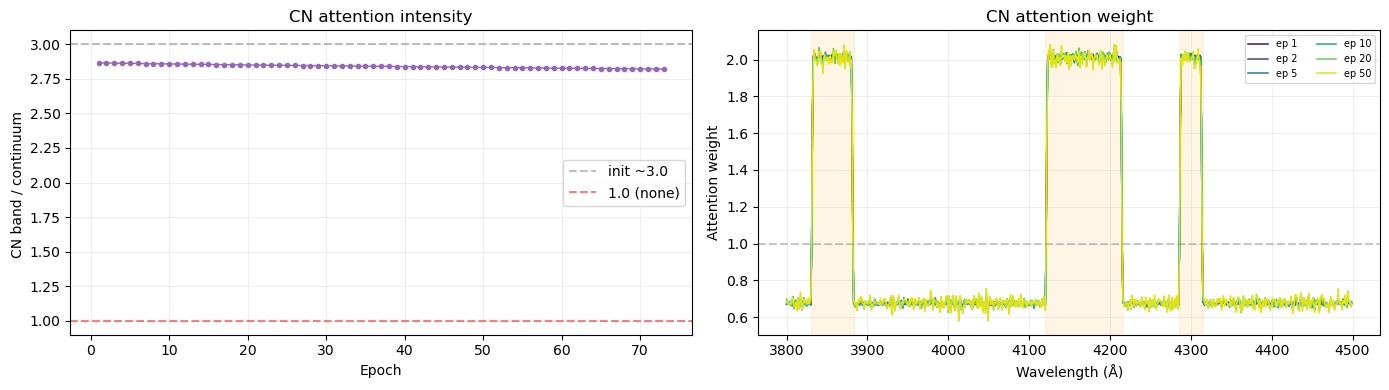

In [23]:
epochs = np.arange(1, len(history['band_weight_ratio']) + 1)
ratio = np.array(history['band_weight_ratio'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs, ratio, 'o-', ms=3, lw=1, color='tab:purple')
axes[0].axhline(3.0, color='gray', ls='--', alpha=0.5, label='init ~3.0')
axes[0].axhline(1.0, color='red', ls='--', alpha=0.5, label='1.0 (none)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CN band / continuum ')
axes[0].set_title('CN attention intensity'); axes[0].legend(); axes[0].grid(alpha=0.2)

cmap = plt.cm.viridis(np.linspace(0.05, 0.95, max(len(snapshots), 1)))
for i, (ep, prof) in enumerate(sorted(snapshots.items())):
    axes[1].plot(common_wave, prof, lw=1.1, color=cmap[i], label=f'ep {ep}')
axes[1].axhline(1.0, color='gray', ls='--', alpha=0.4)
for lo, hi in MOLECULAR_BAND_RANGES:
    axes[1].axvspan(lo, hi, alpha=0.10, color='orange')
axes[1].set_xlabel('Wavelength (Å)'); axes[1].set_ylabel('Attention weight')
axes[1].set_title('CN attention weight'); axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(alpha=0.2)

plt.tight_layout(); plt.show()

## 6. 训练动态与不稳定性诊断

在 ~54 个训练正样本下，模型存在严重过拟合：正样本概率均值 `pos_p` 在 0–1 间剧烈振荡，
这与项目 Phase 4–5 的发现一致。

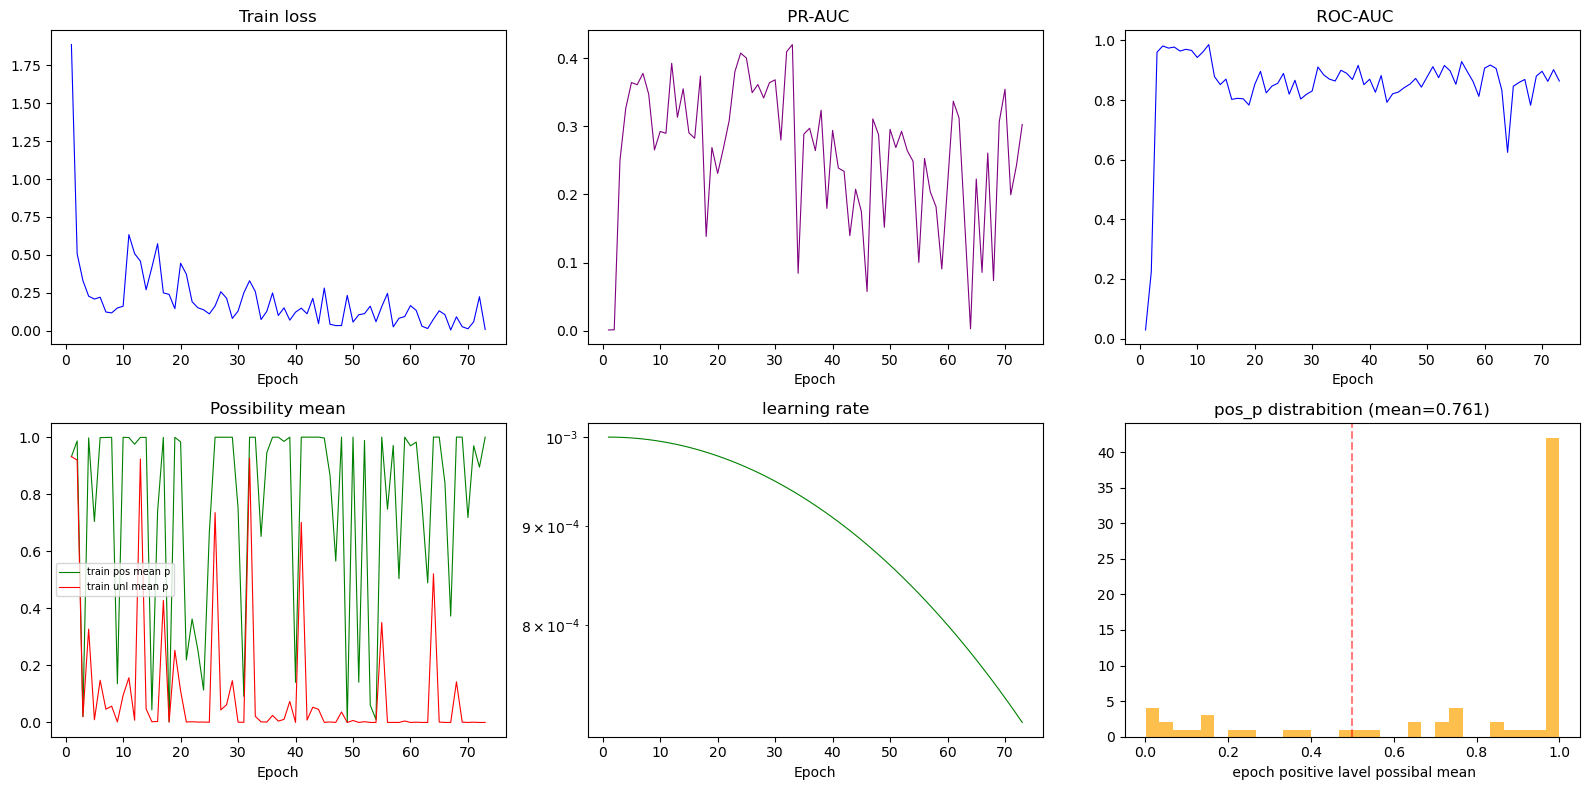

pos_p 范围: [0.000, 1.000]  |  std=0.346
epochs 中 pos_p>0.9: 44/73   pos_p<0.1: 7/73


In [24]:
ep = np.arange(1, len(history['train_loss']) + 1)
pos_p = np.array(history['train_pos_prob_mean'])
unl_p = np.array(history['train_unl_prob_mean'])

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes[0,0].plot(ep, history['train_loss'], 'b-', lw=0.8); axes[0,0].set_title('Train loss'); axes[0,0].set_xlabel('Epoch')
axes[0,1].plot(ep, history['val_pr'], 'purple', lw=0.8); axes[0,1].set_title(' PR-AUC'); axes[0,1].set_xlabel('Epoch')
axes[0,2].plot(ep, history['val_roc'], 'blue', lw=0.8); axes[0,2].set_title(' ROC-AUC'); axes[0,2].set_xlabel('Epoch')
axes[1,0].plot(ep, pos_p, 'g-', lw=0.8, label='train pos mean p')
axes[1,0].plot(ep, unl_p, 'r-', lw=0.8, label='train unl mean p')
axes[1,0].set_title('Possibility mean'); axes[1,0].legend(fontsize=7); axes[1,0].set_xlabel('Epoch')
axes[1,1].plot(ep, history['lr'], 'green', lw=0.8); axes[1,1].set_title('learning rate'); axes[1,1].set_xlabel('Epoch'); axes[1,1].set_yscale('log')
axes[1,2].hist(pos_p, bins=30, color='orange', alpha=0.7)
axes[1,2].axvline(0.5, color='red', ls='--', alpha=0.5)
axes[1,2].set_title(f'pos_p distrabition (mean={pos_p.mean():.3f})'); axes[1,2].set_xlabel(' epoch positive lavel possibal mean')
fig.tight_layout(); plt.show()

print(f'pos_p 范围: [{pos_p.min():.3f}, {pos_p.max():.3f}]  |  std={pos_p.std():.3f}')
print(f'epochs 中 pos_p>0.9: {(pos_p>0.9).sum()}/{len(pos_p)}   pos_p<0.1: {(pos_p<0.1).sum()}/{len(pos_p)}')

## 7. 测试集评估（PR / ROC 曲线）

测试集 (13 正 / 6,172 总):
  AUROC = 0.9044   AUPRC = 0.1533
  P@50 = 0.1000   P@100 = 0.0600   P@200 = 0.0400


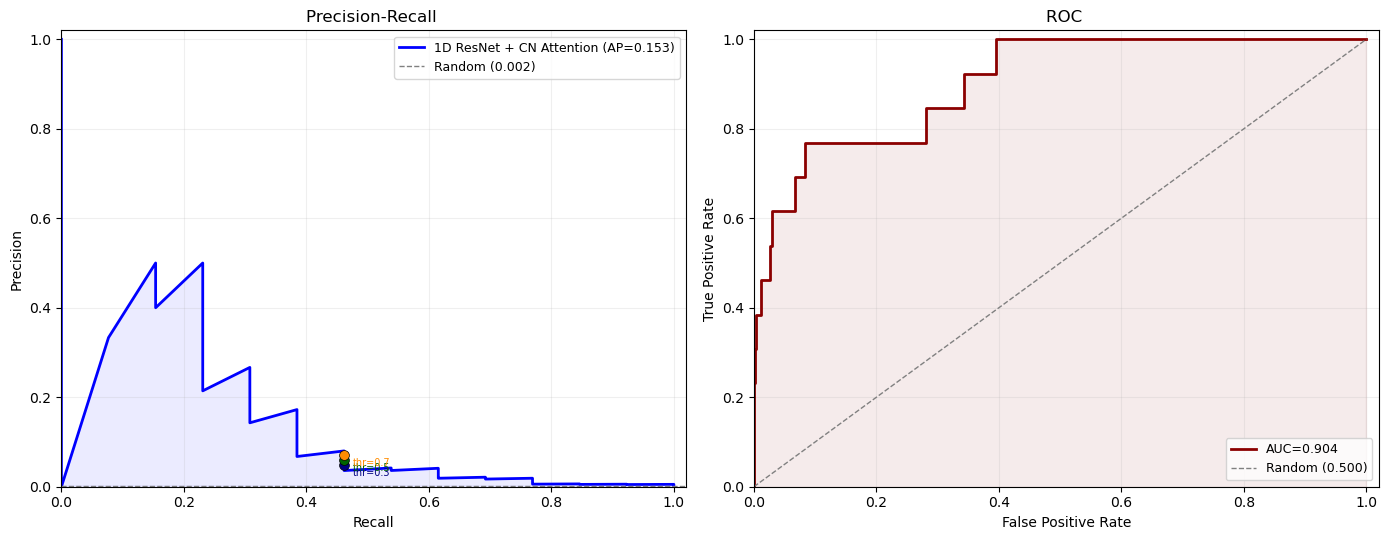

In [25]:
@torch.no_grad()
def predict_batched(X, batch_size=1024):
    model.eval()
    preds = []
    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i+batch_size]).float().to(DEVICE)
        preds.append(model(xb).cpu().numpy())
    return np.concatenate(preds)

test_probs = predict_batched(X_test)
auroc = roc_auc_score(y_test_bin, test_probs)
auprc = average_precision_score(y_test_bin, test_probs)
order = np.argsort(test_probs)[::-1]
def pk(k):
    kk = min(k, len(order)); return y_test_bin[order[:kk]].mean()

print(f"测试集 ({len(test_pos)} 正 / {len(test_unl):,} 总):")
print(f"  AUROC = {auroc:.4f}   AUPRC = {auprc:.4f}")
print(f"  P@50 = {pk(50):.4f}   P@100 = {pk(100):.4f}   P@200 = {pk(200):.4f}")

precision, recall, _ = precision_recall_curve(y_test_bin, test_probs)
fpr, tpr, _ = roc_curve(y_test_bin, test_probs)
baseline = y_test_bin.sum() / len(y_test_bin)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].plot(recall, precision, 'b-', lw=2, label=f'1D ResNet + CN Attention (AP={auprc:.3f})')
axes[0].axhline(baseline, color='gray', ls='--', lw=1, label=f'Random ({baseline:.3f})')
axes[0].fill_between(recall, precision, baseline, alpha=0.08, color='blue')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision'); axes[0].set_title('Precision-Recall ')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.2); axes[0].set_xlim(0,1.02); axes[0].set_ylim(0,1.02)

axes[1].plot(fpr, tpr, 'darkred', lw=2, label=f'AUC={auroc:.3f}')
axes[1].plot([0,1],[0,1],'gray',ls='--',lw=1,label='Random (0.500)')
axes[1].fill_between(fpr, tpr, 0, alpha=0.08, color='darkred')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate'); axes[1].set_title('ROC ')
axes[1].legend(fontsize=9, loc='lower right'); axes[1].grid(alpha=0.2); axes[1].set_xlim(0,1.02); axes[1].set_ylim(0,1.02)

for thr, fmt, c in [(0.3,'thr=0.3','navy'),(0.5,'thr=0.5','darkgreen'),(0.7,'thr=0.7','darkorange')]:
    p_thr = (test_probs >= thr).astype(int)
    tp = ((p_thr==1)&(y_test_bin==1)).sum(); fp = ((p_thr==1)&(y_test_bin==0)).sum()
    fn = ((p_thr==0)&(y_test_bin==1)).sum()
    prec = tp/(tp+fp) if (tp+fp)>0 else 0; rec = tp/(tp+fn) if (tp+fn)>0 else 0
    axes[0].scatter([rec],[prec],s=50,c=c,edgecolors='black',linewidth=0.5,zorder=5)
    axes[0].annotate(fmt,(rec,prec),textcoords='offset points',xytext=(6,-8),fontsize=7,color=c)

plt.tight_layout(); plt.show()

## 8. 已知 CN 星标定阈值 + 候选体筛选

用**已知 CN 星的概率分布**标定阈值——
取已知 CN 星概率的 5% 分位作为阈值，使约 95% 已知 CN 星落在阈值之上；
未标注星中概率 ≥ 阈值者即候选体。

In [26]:
# 在全样本上打分
all_probs = predict_batched(X_clean)

stars_clean['cn_prob'] = all_probs
stars_clean['cn_zscore'] = compute_cluster_zscore(all_probs, stars_clean['masked_cluster_id'].values)

# ── 基于已知 CN 星标定候选阈值（与 XGB 方法一致）──
known_mask = stars_clean['label'] == 1
known_scores = stars_clean.loc[known_mask, 'cn_prob'].values
recall_quantile = 0.05
prob_threshold = float(np.nanquantile(known_scores, recall_quantile))

cand_mask = (stars_clean['label'] == -1) & (stars_clean['cn_prob'] >= prob_threshold)
candidates = stars_clean.loc[cand_mask].sort_values('cn_prob', ascending=False).copy()

n_known_above = int((known_scores >= prob_threshold).sum())
print(f"已知 CN 星概率: min={known_scores.min():.3f}  q05={np.nanquantile(known_scores,0.05):.3f}  "
      f"median={np.nanmedian(known_scores):.3f}  max={known_scores.max():.3f}")
print(f"标定阈值 (保留 ~95% 已知 CN 星): prob_threshold = {prob_threshold:.4f}")
print(f"已知 CN 星中 >= 阈值: {n_known_above}/{len(known_scores)}")
print(f"未标注候选体数量: {len(candidates)}  ({len(candidates)/N*100:.2f}%)")

已知 CN 星概率: min=0.001  q05=0.001  median=1.000  max=1.000
标定阈值 (保留 ~95% 已知 CN 星): prob_threshold = 0.0008
已知 CN 星中 >= 阈值: 86/91
未标注候选体数量: 10790  (26.16%)


## 9. 候选体可视化

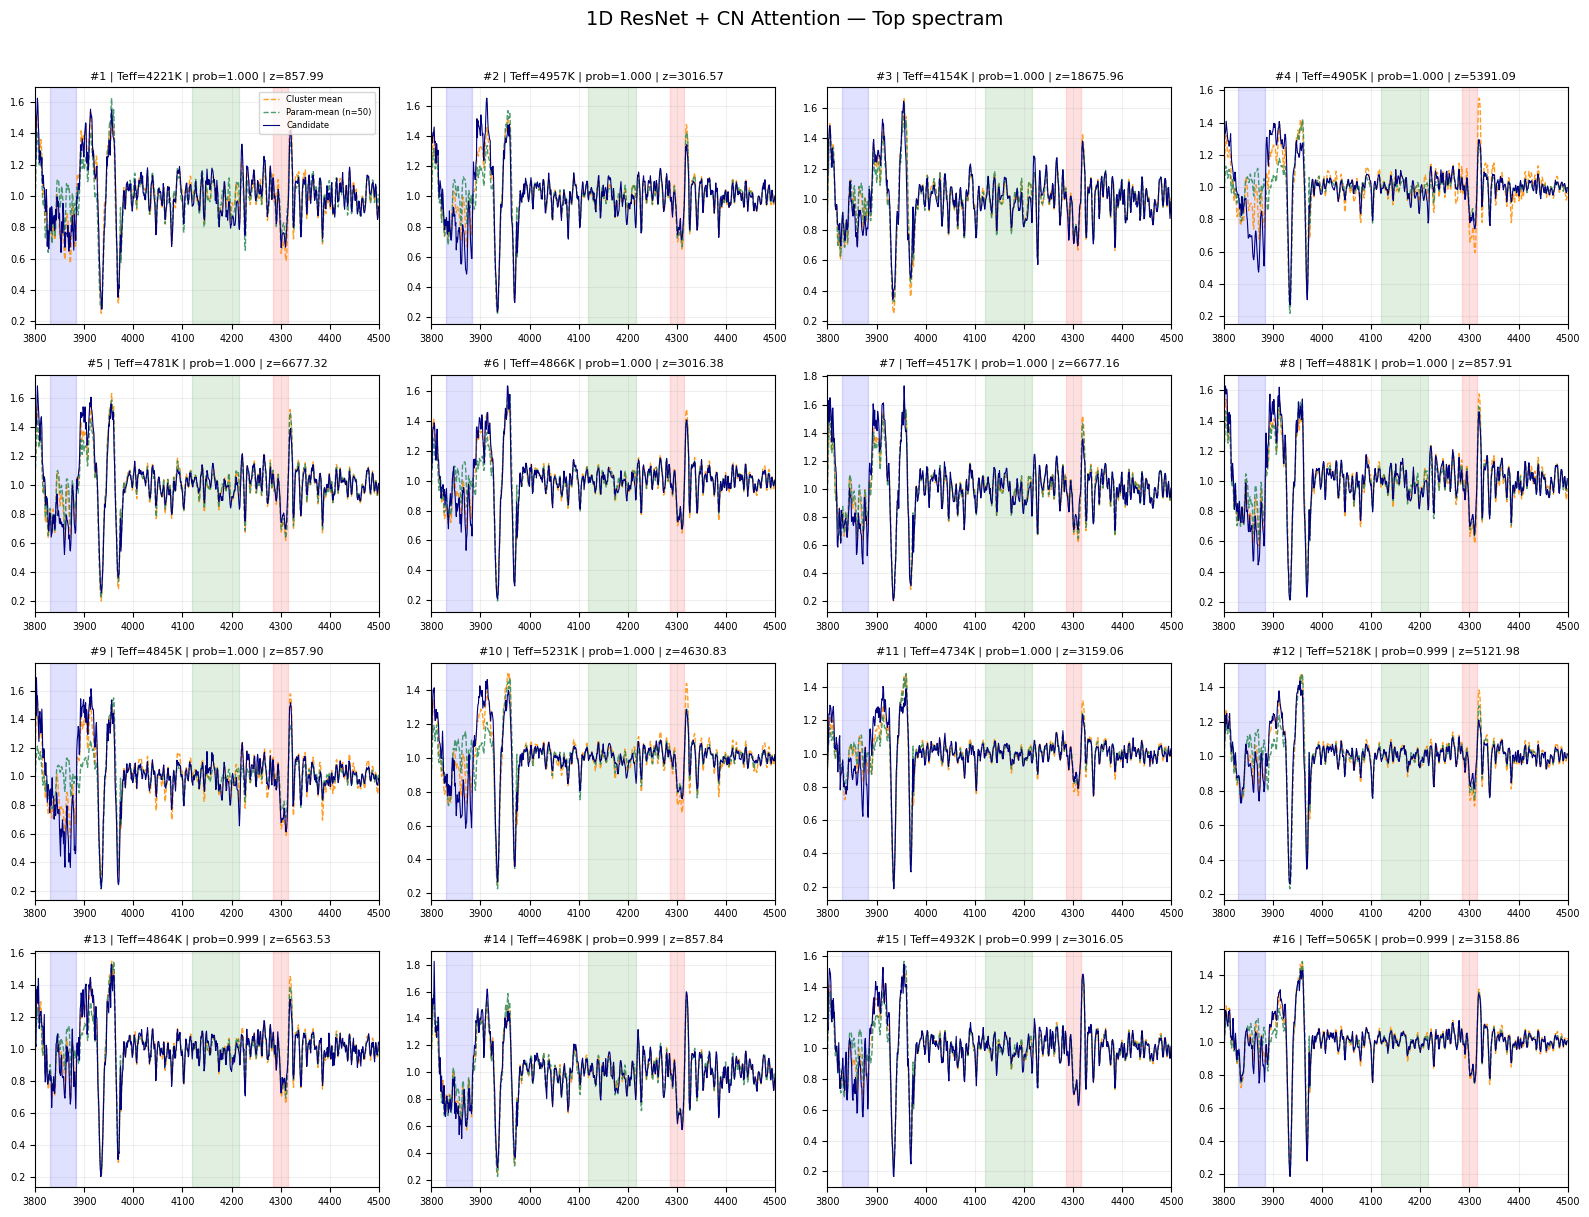

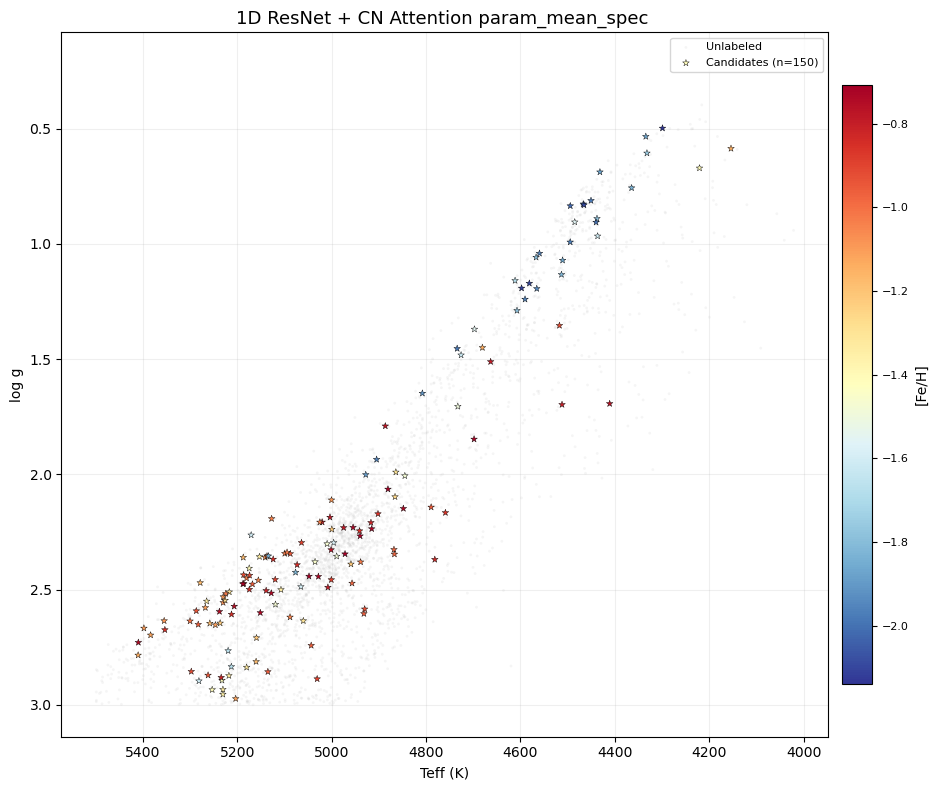

In [27]:
# 参数近邻平均光谱辅助函数（参数相近恒星的典型光谱对比线）
_param_cols = ('teff', 'logg', 'feh')
n_param_nn = 50

def build_param_nn(stars, param_cols=_param_cols, n_neighbors=n_param_nn):
    P = stars[list(param_cols)].to_numpy(dtype=float)
    mu = np.nanmean(P, axis=0); sd = np.nanstd(P, axis=0); sd = np.where(sd==0, 1.0, sd)
    Ps = (P - mu) / sd
    nn = NearestNeighbors(n_neighbors=min(n_neighbors+1, len(P)), metric='euclidean').fit(Ps)
    return nn, Ps

def param_mean_spec(idx, nn, Ps, X, n_neighbors=n_param_nn):
    _, nbr = nn.kneighbors(Ps[idx].reshape(1,-1), n_neighbors=n_neighbors+1)
    nbr = nbr[0]; nbr = nbr[nbr != idx]; nbr = nbr[:n_neighbors]
    return np.nanmedian(X[nbr], axis=0)

param_nn, Ps_all = build_param_nn(stars_clean)

# ── 候选体光谱（含簇内平均 + 参数相近平均对比线）──
top_n = 16
cand_vis = candidates.head(top_n)
cluster_means = {}
for cid in candidates['masked_cluster_id'].unique():
    cmask = stars_clean['masked_cluster_id'] == cid
    cluster_means[cid] = np.nanmedian(X_clean[stars_clean.index[cmask]], axis=0)

fig, axes = plt.subplots(4, 4, figsize=(16, 12)); axes = axes.flatten()
for i, idx in enumerate(cand_vis.index):
    ax = axes[i]; flux = X_clean[idx]; cid = cand_vis.loc[idx, 'masked_cluster_id']
    if cid in cluster_means:
        ax.plot(common_wave, cluster_means[cid], color='darkorange', lw=1.0, ls='--', alpha=0.85, label='Cluster mean')
    ax.plot(common_wave, param_mean_spec(idx, param_nn, Ps_all, X_clean), color='seagreen', lw=1.0, ls='--', alpha=0.85, label=f'Param-mean (n={n_param_nn})')
    ax.plot(common_wave, flux, color='navy', lw=0.8, label='Candidate')
    for l1, l2, c in [(3830,3883,'blue'),(4120,4216,'green'),(4285,4315,'red')]:
        ax.axvspan(l1, l2, alpha=0.12, color=c, zorder=0)
    teff = cand_vis.loc[idx, 'teff']; prob = cand_vis.loc[idx, 'cn_prob']; z = cand_vis.loc[idx, 'cn_zscore']
    ax.set_title(f"#{i+1} | Teff={teff:.0f}K | prob={prob:.3f} | z={z:.2f}", fontsize=8)
    ax.set_xlim(3800, 4500); ax.tick_params(labelsize=7); ax.grid(alpha=0.2)
    if i == 0: ax.legend(fontsize=6, loc='upper right')
for j in range(top_n, len(axes)): axes[j].axis('off')
fig.suptitle('1D ResNet + CN Attention — Top spectram', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

# ── Teff-logg-feh 参数分布 ──
fig, ax = plt.subplots(figsize=(10, 8))
rng_np = np.random.RandomState(42)
bg_mask = stars_clean['label'] == -1
bg_sample = rng_np.choice(np.where(bg_mask)[0], 3000, replace=False)
ax.scatter(stars_clean.iloc[bg_sample]['teff'], stars_clean.iloc[bg_sample]['logg'],
           s=4, alpha=0.12, c='#b0b0b0', edgecolors='none', label='Unlabeled')
top_plot = min(150, len(candidates)); cand_plot = candidates.head(top_plot)
sc = ax.scatter(cand_plot['teff'], cand_plot['logg'], s=25, c=cand_plot['feh'],
                cmap='RdYlBu_r', marker='*',edgecolors='black', linewidth=0.3, label=f'Candidates (n={len(cand_plot)})', zorder=2)
cbar = plt.colorbar(sc, ax=ax, label='[Fe/H]', shrink=0.85, pad=0.015); cbar.ax.tick_params(labelsize=8)
ax.set_xlabel('Teff (K)'); ax.set_ylabel('log g'); ax.invert_xaxis(); ax.invert_yaxis()
ax.legend(fontsize=8, loc='upper right'); ax.grid(alpha=0.2)
ax.set_title('1D ResNet + CN Attention param_mean_spec ', fontsize=13)
plt.tight_layout(); plt.show()

## 10. 导出候选体

In [28]:
out_cols = ['uid','ra','dec','teff','logg','feh','label','snru','cn_prob','cn_zscore','masked_cluster_id']
out_cols = [c for c in out_cols if c in candidates.columns]
out_df = candidates[out_cols].copy()
outpath = str(_PROJECT_ROOT / 'EndToEndPU' / 'EndToEndPU_candidates_threshold.csv')
out_df.to_csv(outpath, index=False)
print(f"候选体已导出: {outpath}")
print(f"筛选阈值 prob_threshold = {prob_threshold:.4f}")
print(f"候选体统计 (共 {len(out_df)} 颗):")
print(f"  prob > 0.5: {(out_df['cn_prob']>0.5).sum()}  |  prob > 0.7: {(out_df['cn_prob']>0.7).sum()}")
if 'cn_zscore' in out_df.columns:
    print(f"  z > 2.0: {(out_df['cn_zscore']>2.0).sum()}  |  z > 3.0: {(out_df['cn_zscore']>3.0).sum()}")

候选体已导出: D:\资料\2026大创\Lamost\EndToEndPU\EndToEndPU_candidates_threshold.csv
筛选阈值 prob_threshold = 0.0008
候选体统计 (共 10790 颗):
  prob > 0.5: 671  |  prob > 0.7: 554
  z > 2.0: 7238  |  z > 3.0: 6209


## 11. 结论


- **CN 注意力机制有效**：将 AUPRC 显著提升，验证 "关注 CN 带" 在分类网络中的有效性
- **深度学习受限于样本量**：在 ~54 个正样本的极端不平衡下，深度网络（~3.8M 参数）不及 XGBoost PU Bagging 标杆
- **已知 CN 星标定阈值**：提供物理可解释的候选体筛选，与 XGB 方法一致，便于两种方法交叉验证

## 12. nnPU 版本对照实验

保持其余超参完全一致，仅将损失函数 `weighted_bce` 切换为 `nnPU`
（Kiryo et al. 2017 非负 PU 风险估计），对比二者在测试集上的表现。

- 原版：`loss_mode='weighted_bce'`（pos_weight=10）
- 对照：`loss_mode='nnpu'`（π_p 自动按 n_pos/n_total ≈ 0.0023 计算）

In [29]:
# ── nnPU 版本：仅改损失函数，其余超参一致 ──
config_nnpu = EndToEndPUConfig(
    use_cn_attention=True,
    cn_band_weight_init=3.0,
    base_ch=64,
    dropout=0.3,
    se_reduction=8,
    res_blocks=4,
    learning_rate=1e-3,
    weight_decay=1e-2,
    batch_size=64,
    n_epochs=200,
    early_stopping_patience=40,
    loss_mode='nnpu',          # 与原版的唯一差异
    positive_weight=10.0,      # 仅 weighted_bce 使用，nnPU 下忽略
    neg_ratio=1.0,
    mixup_alpha=0.2,
    pos_augment=True,
    grad_clip=1.0,
    hard_neg_frac=0.3,
    random_seed=SEED,
    device=DEVICE,
)

model_nnpu = create_model(config_nnpu)
print(f"nnPU 模型参数量: {sum(p.numel() for p in model_nnpu.parameters()):,}")

trainer_nnpu = EndToEndPUTrainer(model_nnpu, config_nnpu)
res_nnpu = trainer_nnpu.train(
    X_train_pos=X_train_pos,
    X_train_unl=X_train_unl,
    X_val=X_val,
    y_val_bin=y_val_bin,
    wave=common_wave if config_nnpu.pos_augment else None,
    verbose=True,
)
model_nnpu = res_nnpu['model']
print(f"nnPU 最优 epoch={res_nnpu['best_epoch']}  "
      f"val PR={res_nnpu['best_val_pr']:.4f}  ROC={res_nnpu['best_val_roc']:.4f}")

nnPU 模型参数量: 3,814,269
  *Ep   1/200 | loss=0.2081 | pos_p=0.050 unl_p=0.0499 | val_pr=0.0271 val_roc=0.8962 | best=0.0271@1
  *Ep   4/200 | loss=0.0186 | pos_p=0.005 unl_p=0.0049 | val_pr=0.0299 val_roc=0.9275 | best=0.0299@4
  *Ep   5/200 | loss=0.0176 | pos_p=0.004 unl_p=0.0038 | val_pr=0.0549 val_roc=0.9394 | best=0.0549@5
  *Ep   6/200 | loss=0.0172 | pos_p=0.003 unl_p=0.0032 | val_pr=0.0562 val_roc=0.9511 | best=0.0562@6
  *Ep   7/200 | loss=0.0170 | pos_p=0.003 unl_p=0.0028 | val_pr=0.0778 val_roc=0.9486 | best=0.0778@7
  *Ep   8/200 | loss=0.0170 | pos_p=0.003 unl_p=0.0025 | val_pr=0.1213 val_roc=0.9571 | best=0.1213@8
  *Ep   9/200 | loss=0.0169 | pos_p=0.003 unl_p=0.0025 | val_pr=0.1778 val_roc=0.9547 | best=0.1778@9
  *Ep  10/200 | loss=0.0140 | pos_p=0.053 unl_p=0.0023 | val_pr=0.3267 val_roc=0.9771 | best=0.3267@10
   Ep  20/200 | loss=0.0088 | pos_p=0.134 unl_p=0.0008 | val_pr=0.2793 val_roc=0.9322 | best=0.3267@10
  *Ep  22/200 | loss=0.0090 | pos_p=0.256 unl_p=0.0006 | v

In [30]:
# nnPU 测试集评估
@torch.no_grad()
def predict_batched_nnpu(X, batch_size=1024):
    model_nnpu.eval()
    preds = []
    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i+batch_size]).float().to(DEVICE)
        preds.append(model_nnpu(xb).cpu().numpy())
    return np.concatenate(preds)

test_probs_nnpu = predict_batched_nnpu(X_test)
auroc_n = roc_auc_score(y_test_bin, test_probs_nnpu)
auprc_n = average_precision_score(y_test_bin, test_probs_nnpu)
order_n = np.argsort(test_probs_nnpu)[::-1]
def pk_n(k):
    kk = min(k, len(order_n)); return y_test_bin[order_n[:kk]].mean()

print(f"nnPU 测试集 ({len(test_pos)} 正 / {len(test_unl):,} 总):")
print(f"  AUROC = {auroc_n:.4f}   AUPRC = {auprc_n:.4f}")
print(f"  P@50 = {pk_n(50):.4f}   P@100 = {pk_n(100):.4f}   P@200 = {pk_n(200):.4f}")

# nnPU 全样本打分 + 阈值标定候选体
all_probs_n = predict_batched_nnpu(X_clean)
stars_clean['cn_prob_nnpu'] = all_probs_n
known_scores_n = stars_clean.loc[stars_clean['label']==1, 'cn_prob_nnpu'].values
thr_n = float(np.nanquantile(known_scores_n, 0.05))
cand_n = stars_clean.loc[(stars_clean['label']==-1) & (stars_clean['cn_prob_nnpu']>=thr_n)]

print(f"nnPU 已知 CN 星概率: min={known_scores_n.min():.3f}  q05={np.nanquantile(known_scores_n,0.05):.3f}  "
      f"median={np.nanmedian(known_scores_n):.3f}  max={known_scores_n.max():.3f}")
print(f"nnPU 阈值={thr_n:.4f}  未标注候选体: {len(cand_n)}  ({len(cand_n)/N*100:.2f}%)")

# ── 与原版 weighted_bce 对照（原版指标见第 7 节）──
print("\n" + "=" * 56)
print("损失函数对照 (测试集):")
print(f"  {'':16s} {'AUROC':>8s} {'AUPRC':>8s} {'P@50':>7s} {'P@100':>7s}")
print(f"  {'weighted_bce':16s} {auroc:>8.4f} {auprc:>8.4f} {pk(50):>7.4f} {pk(100):>7.4f}")
print(f"  {'nnPU':16s} {auroc_n:>8.4f} {auprc_n:>8.4f} {pk_n(50):>7.4f} {pk_n(100):>7.4f}")
print("=" * 56)

nnPU 测试集 (13 正 / 6,172 总):
  AUROC = 0.9456   AUPRC = 0.3070
  P@50 = 0.1000   P@100 = 0.0600   P@200 = 0.0350
nnPU 已知 CN 星概率: min=0.001  q05=0.008  median=0.989  max=0.990
nnPU 阈值=0.0075  未标注候选体: 6551  (15.88%)

损失函数对照 (测试集):
                      AUROC    AUPRC    P@50   P@100
  weighted_bce       0.9044   0.1533  0.1000  0.0600
  nnPU               0.9456   0.3070  0.1000  0.0600
